In [ ]:
import os
import pandas as pd
import gensim
import gensim.corpora as corpora
from gensim.models import CoherenceModel
import matplotlib.pyplot as plt 

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module='gensim')


In [ ]:
# Load the preprocessed complaints data into a DataFrame

df = pd.read_csv('../data/complaints_processed_full.csv')
df.head()



,product,narrative
0,credit_reporting,account
1,credit_reporting,wrote three request unverified account listed ...
2,credit_reporting,recently going check new car carefully conside...
3,mortgages_and_loans,call hour weekend using various number
4,credit_reporting,notified experian inaccuracy report national c...


In [8]:
# Create a list of tokenized narratives

tokenized = df['narrative'].str.split().tolist()


In [10]:
# Build GenSim dictionary and corpus for topic modeling
dictionary = corpora.Dictionary(tokenized)
corpus = [dictionary.doc2bow(text) for text in tokenized]

In [11]:
# Evaluate coherence scores for different numbers of topics to select the optimal number of topics

candidate_topics = [5, 10, 15, 20, 25, 30]
coherence_scores = []

for k in candidate_topics:
    lda_model = gensim.models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=10
    )
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=tokenized,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence_scores.append(coherence_model.get_coherence())
    print(f"num_topics={k}, coherence={coherence_scores[-1]:.4f}")

num_topics=5, coherence=0.5259
num_topics=10, coherence=0.5313
num_topics=15, coherence=0.5291
num_topics=20, coherence=0.5263
num_topics=25, coherence=0.5039
num_topics=30, coherence=0.4990


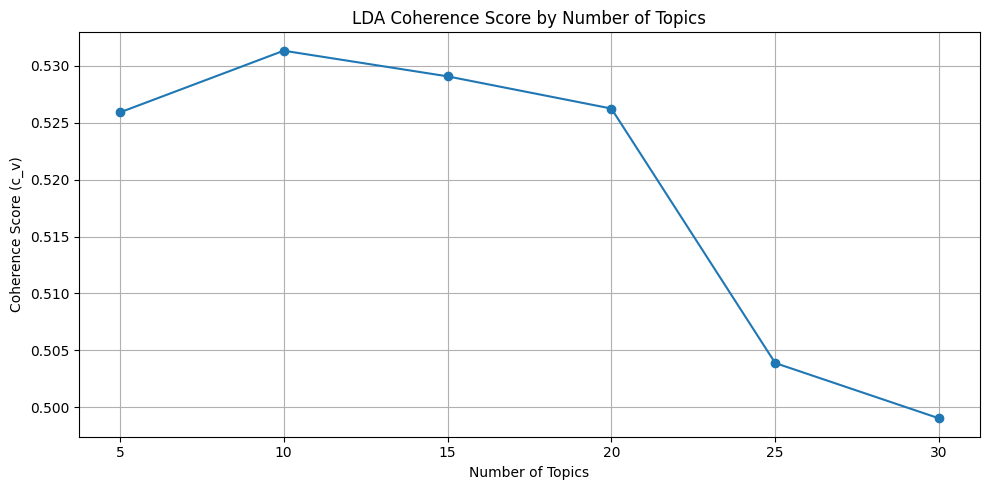

In [13]:
# Plot coherence scores to visualize the optimal number of topics

plt.figure(figsize=(10, 5))
plt.plot(candidate_topics, coherence_scores, marker='o')
plt.xlabel('Number of Topics')
plt.ylabel('Coherence Score (c_v)')
plt.title('LDA Coherence Score by Number of Topics')
plt.xticks(candidate_topics)
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
# Train the final LDA model using the optimal number of topics based on coherence scores

optimal_k = candidate_topics[coherence_scores.index(max(coherence_scores))]
print(f"Selected num_topics: {optimal_k}")

lda_final = gensim.models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=optimal_k,
    random_state=42,
    passes=10
)

Selected num_topics: 10


In [18]:
# Inspect topic-word distributions

for idx, topic in lda_final.print_topics(num_words=10):
    print(f"Topic {idx}: {topic}")

Topic 0: 0.085*"debt" + 0.055*"credit" + 0.050*"collection" + 0.039*"inquiry" + 0.036*"company" + 0.028*"report" + 0.015*"agency" + 0.014*"account" + 0.014*"never" + 0.012*"owe"
Topic 1: 0.040*"letter" + 0.030*"sent" + 0.024*"dispute" + 0.023*"information" + 0.021*"received" + 0.015*"response" + 0.014*"day" + 0.013*"request" + 0.012*"complaint" + 0.012*"proof"
Topic 2: 0.018*"consumer" + 0.017*"act" + 0.016*"law" + 0.012*"debt" + 0.012*"right" + 0.012*"violation" + 0.012*"reporting" + 0.011*"fair" + 0.011*"legal" + 0.010*"credit"
Topic 3: 0.073*"payment" + 0.018*"paid" + 0.018*"month" + 0.017*"due" + 0.017*"late" + 0.014*"pay" + 0.014*"balance" + 0.013*"fee" + 0.012*"amount" + 0.012*"time"
Topic 4: 0.049*"information" + 0.042*"consumer" + 0.024*"credit" + 0.024*"reporting" + 0.024*"account" + 0.021*"report" + 0.020*"agency" + 0.019*"section" + 0.014*"identity" + 0.013*"file"
Topic 5: 0.138*"credit" + 0.074*"report" + 0.045*"account" + 0.035*"reporting" + 0.028*"information" + 0.023*"bu

In [19]:
# Extract document-topic vectors and assign dominant topic to each document

import numpy as np

def get_doc_topic_vector(bow, model, num_topics):
    topic_dist = dict(model.get_document_topics(bow, minimum_probability=0.0))
    return [topic_dist.get(i, 0.0) for i in range(num_topics)]

topic_vectors = np.array([
    get_doc_topic_vector(bow, lda_final, optimal_k)
    for bow in corpus
])

topic_df = pd.DataFrame(
    topic_vectors,
    columns=[f'topic_{i}' for i in range(optimal_k)]
)
topic_df.head()

,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9
0,0.050002,0.050002,0.050001,0.050001,0.050004,0.050007,0.050000,0.050007,0.549976,0.050000
1,0.001177,0.392212,0.285205,0.001177,0.238433,0.001177,0.001177,0.001177,0.077090,0.001177
2,0.002705,0.002705,0.002705,0.392848,0.002705,0.343998,0.002705,0.002705,0.002705,0.244220
3,0.014290,0.014292,0.014291,0.014291,0.014290,0.014291,0.871376,0.014294,0.014294,0.014292
4,0.171339,0.112644,0.002706,0.002706,0.002706,0.556267,0.143514,0.002706,0.002706,0.002706
